In [1]:
###-----------------
### Import libraries
###-----------------
import os
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler,LabelEncoder  # Import for standardizing features (zero mean, unit variance)
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility

\begin{align*}
& X \rightarrow X \cdot W_1 + b_1 \rightarrow \text{activation fnc }(g) \text{ (i.e. } a_1) \rightarrow a_1 \cdot W_2 + b_2 \rightarrow \text{(output } a_2) \rightarrow \text{Loss calculate} \\
& \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad|\\
& \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad dz_2 = (a_2 - y) \leftarrow \\
& \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad dw_2 = (a_1 \cdot dz_2) \\
& \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad db = dz_2 \\
& \\
& a_1 = g(z_1) \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad da_1 = W \cdot dz_2 \\
& \frac{\partial}{\partial a_1} = da_1 \\
& dz_1 = \frac{\partial L}{\partial a_1} \frac{\partial a_1}{\partial z_1} \\
& \\
& dw_1 = X \cdot dz_1 \\
& db_1 = dz_1
\end{align*}

In [2]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

EPOCHS = 20 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2
TRAIN_SIZE = 454 * BATCH_SIZE
# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
train_filename = os.path.join(inpDir, 'fashion_mnist', 'fashion-mnist_train.csv')
test_filename = os.path.join(inpDir, 'fashion_mnist', 'fashion-mnist_test.csv')

train_df = pd.read_csv('input/fashion_mnist/fashion-mnist_train.csv',header=0)
test_df = pd.read_csv('input/fashion_mnist/fashion-mnist_test.csv', header = 0)

In [5]:
class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [6]:
class GlobalScaler:
    _instance = None
    def __init__(self):
        if GlobalScaler._instance is not None:
            raise Exception('GlobalScaler is Singleton Class')
        self.scaler = StandardScaler()
    @classmethod
    def get_instance(cls):
        if cls._instance is None:
            cls._instance = GlobalScaler()
        return cls._instance

In [7]:
class mnist(Dataset):
    globalScaler = GlobalScaler.get_instance() # protected variable 
    def __init__(self,dataframe ,is_train,label_col,device = device):
        self.df = dataframe
        self.device = device
        self.is_train = is_train
        self.scaler = self.globalScaler.scaler
        self.label_col = label_col

        self.labels = self.df[label_col].to_numpy()
        if self.is_train:
            X = self.df.drop(label_col , axis = 1)
            self.features = self.scaler.fit_transform(X)
        else:
            X = self.df.drop(label_col, axis = 1)
            self.features = self.scaler.transform(X)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        feature = self.features[index]
        label = self.labels[index]

        feature = torch.tensor(feature,dtype = torch.float32,device = self.device)
        label = torch.tensor(label,dtype = torch.int64,device = self.device)
        
        return feature,label

In [8]:
# train_df.reset_index(drop = True)
# test_df.reset_index(drop = True)

In [9]:
#scaling using singleton class pattern
label_col = 'label'
train_df = mnist(train_df,is_train=True,label_col = label_col)
test_df = mnist(test_df,is_train=False,label_col = label_col)

In [10]:
train_loader = DataLoader(train_df,batch_size=BATCH_SIZE,shuffle=True) #to covert data to batches
test_loader = DataLoader(test_df,batch_size=BATCH_SIZE,shuffle=True)


for count,data in enumerate(train_df):
    feat,lbl = data
    print(f'Count : {count},label : {lbl}, size : {feat.shape}')

Count : 0,label : 2, size : torch.Size([784])
Count : 1,label : 9, size : torch.Size([784])
Count : 2,label : 6, size : torch.Size([784])
Count : 3,label : 0, size : torch.Size([784])
Count : 4,label : 3, size : torch.Size([784])
Count : 5,label : 4, size : torch.Size([784])
Count : 6,label : 4, size : torch.Size([784])
Count : 7,label : 5, size : torch.Size([784])
Count : 8,label : 4, size : torch.Size([784])
Count : 9,label : 8, size : torch.Size([784])
Count : 10,label : 0, size : torch.Size([784])
Count : 11,label : 8, size : torch.Size([784])
Count : 12,label : 9, size : torch.Size([784])
Count : 13,label : 0, size : torch.Size([784])
Count : 14,label : 2, size : torch.Size([784])
Count : 15,label : 2, size : torch.Size([784])
Count : 16,label : 9, size : torch.Size([784])
Count : 17,label : 3, size : torch.Size([784])
Count : 18,label : 3, size : torch.Size([784])
Count : 19,label : 3, size : torch.Size([784])
Count : 20,label : 8, size : torch.Size([784])
Count : 21,label : 7, s

<h1>Model Creation</h1>

In [11]:
class Model(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        dor1 = 0.1
        dor2 = 0.2
        dor3 = 0.3
        out_dim_1 = 146
        self.layer1 = nn.Linear(input_dim,out_dim_1)
        self.bn1 = nn.BatchNorm1d(out_dim_1)
        self.actv1 = nn.ReLU()
        self.do1 = nn.Dropout(dor1)
    
        out_dim_2 = 36
        self.layer2 = nn.Linear(out_dim_1,out_dim_2)
        self.bn2 = nn.BatchNorm1d(out_dim_2)
        self.actv2 = nn.ReLU()
        self.do2 = nn.Dropout(dor2)
    
        
        self.layer3 = nn.Linear(out_dim_2,10)
        self.actv3 = nn.ReLU()

    def forward(self,x):
        x =  self.do1(self.actv1(self.bn1(self.layer1(x))))
        x =  self.do2(self.actv2(self.bn2(self.layer2(x))))
        x = self.layer3(x)
        return x
model = Model(input_dim=784).to(device)
print(model)
        

Model(
  (layer1): Linear(in_features=784, out_features=146, bias=True)
  (bn1): BatchNorm1d(146, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv1): ReLU()
  (do1): Dropout(p=0.1, inplace=False)
  (layer2): Linear(in_features=146, out_features=36, bias=True)
  (bn2): BatchNorm1d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv2): ReLU()
  (do2): Dropout(p=0.2, inplace=False)
  (layer3): Linear(in_features=36, out_features=10, bias=True)
  (actv3): ReLU()
)


<h1>Training model</h1>

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = ALPHA,weight_decay=1e-5)


# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(abs)

loss,tloss = [],[] 
acc,tacc = [],[]
n_epoch = []

for epoch in range(EPOCHS):
    model.train() #training mode
    train_loss = 0.0
    train_acc = 0.0
 
    for i,data in enumerate(train_loader): #data loader contains batches of dataset and gives index and batch as output
        inputs,labels = data #data[0] -> input datas || #data[1] -> output label
        optimizer.zero_grad() #sets previous grads as zero
        outputs = model(inputs) #get output for data[0](inputs) output -> logits
        preds = torch.argmax(outputs,axis = 1) #predict 

        batch_loss = loss_fn(outputs,labels)
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
        batch_loss.backward()
        optimizer.step()
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)

    train_loss = train_loss/len(train_df)
    train_acc = train_acc/len(train_df)
    
    loss.append(train_loss)
    acc.append(train_acc)

    with torch.no_grad():
        model.eval()  #
        test_loss = 0.0
        test_acc = 0.0
    
        for i,data in enumerate(test_loader):
            inputs,labels = data
            outputs = model(inputs)
            preds = torch.argmax(outputs,axis = 1)
    
            batch_loss = loss_fn(outputs,labels)
            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
            test_loss += batch_loss.item() * inputs.size(0)
            test_acc += batch_acc * inputs.size(0)
    
        test_loss = test_loss/len(train_df)
        test_acc = test_acc/len(train_df)
        
        tloss.append(test_loss)
        tacc.append(test_acc)
    n_epoch.append(epoch)
    # scheduler.step(test_loss)
    if epoch%10 == 0:
        print(f'Epoch : {epoch} | Traing_loss : {train_loss} | Training_Accuracy : {train_acc} | Test_loss : {test_loss} | Testing_Accuracy : {test_acc}')

Epoch : 0 | Traing_loss : 0.57730153743426 | Training_Accuracy : 0.8094 | Test_loss : 0.06295399808883667 | Testing_Accuracy : 0.14421666666666666
Epoch : 10 | Traing_loss : 0.29164366688330967 | Training_Accuracy : 0.8940166666666667 | Test_loss : 0.050426518048842746 | Testing_Accuracy : 0.14811666666666667


In [13]:
#train_loader = DataLoader(train_df,batch_size=BATCH_SIZE,shuffle=True) ---> to covert data to batches


for i,data in enumerate(train_loader): #trainloader giving list of tuples containing index(i) and batch(data)
    print(data[1]) #data[0]  -> X | data[1] ->y
    outputs = model(data[0]) #output for every batch
    print(torch.argmax(outputs,axis = 1)) #taking argmax of output to selected class with maximum logit
    

tensor([3, 3, 7, 7, 4, 9, 2, 9, 5, 7, 6, 3, 9, 0, 7, 7, 9, 5, 6, 1, 3, 5, 3, 0,
        7, 5, 7, 4, 9, 8, 9, 6])
tensor([3, 3, 7, 7, 4, 9, 2, 7, 5, 7, 6, 3, 9, 0, 7, 7, 9, 5, 6, 1, 3, 5, 3, 0,
        7, 5, 7, 2, 9, 8, 9, 6])
tensor([5, 1, 1, 3, 8, 8, 6, 8, 0, 6, 7, 6, 6, 4, 2, 0, 5, 0, 9, 5, 3, 0, 9, 6,
        3, 5, 4, 6, 1, 8, 0, 0])
tensor([5, 1, 1, 3, 8, 8, 2, 8, 0, 0, 7, 4, 0, 4, 2, 0, 5, 0, 9, 5, 3, 3, 9, 6,
        3, 5, 4, 6, 1, 8, 0, 6])
tensor([6, 1, 3, 7, 0, 6, 3, 9, 1, 3, 2, 2, 5, 3, 9, 0, 1, 5, 5, 1, 0, 6, 5, 5,
        2, 8, 8, 0, 7, 9, 7, 7])
tensor([6, 1, 3, 7, 0, 4, 3, 9, 1, 3, 2, 2, 5, 3, 9, 0, 1, 5, 5, 1, 0, 6, 5, 5,
        0, 8, 8, 0, 7, 9, 7, 7])
tensor([8, 6, 7, 6, 0, 7, 7, 8, 0, 3, 3, 7, 2, 5, 0, 6, 2, 4, 4, 1, 3, 5, 0, 3,
        9, 3, 4, 7, 0, 6, 5, 0])
tensor([8, 6, 7, 6, 0, 7, 7, 8, 0, 2, 3, 7, 2, 5, 6, 6, 2, 4, 4, 1, 3, 5, 0, 3,
        9, 3, 4, 7, 0, 6, 5, 0])
tensor([4, 9, 0, 8, 4, 9, 2, 8, 7, 9, 4, 2, 5, 5, 3, 1, 4, 9, 3, 6, 4, 1, 6, 7,
        4, 2, 3,

In [14]:
outputs.shape,labels.shape

(torch.Size([32, 10]), torch.Size([16]))

,epoch,loss,test_loss,acc,test_acc
0,0,0.577302,0.062954,0.809400,0.144217
1,1,0.427842,0.058602,0.847217,0.145467
2,2,0.392352,0.054566,0.861450,0.146233
3,3,0.369846,0.052955,0.867967,0.146750
4,4,0.350408,0.051275,0.875650,0.147967


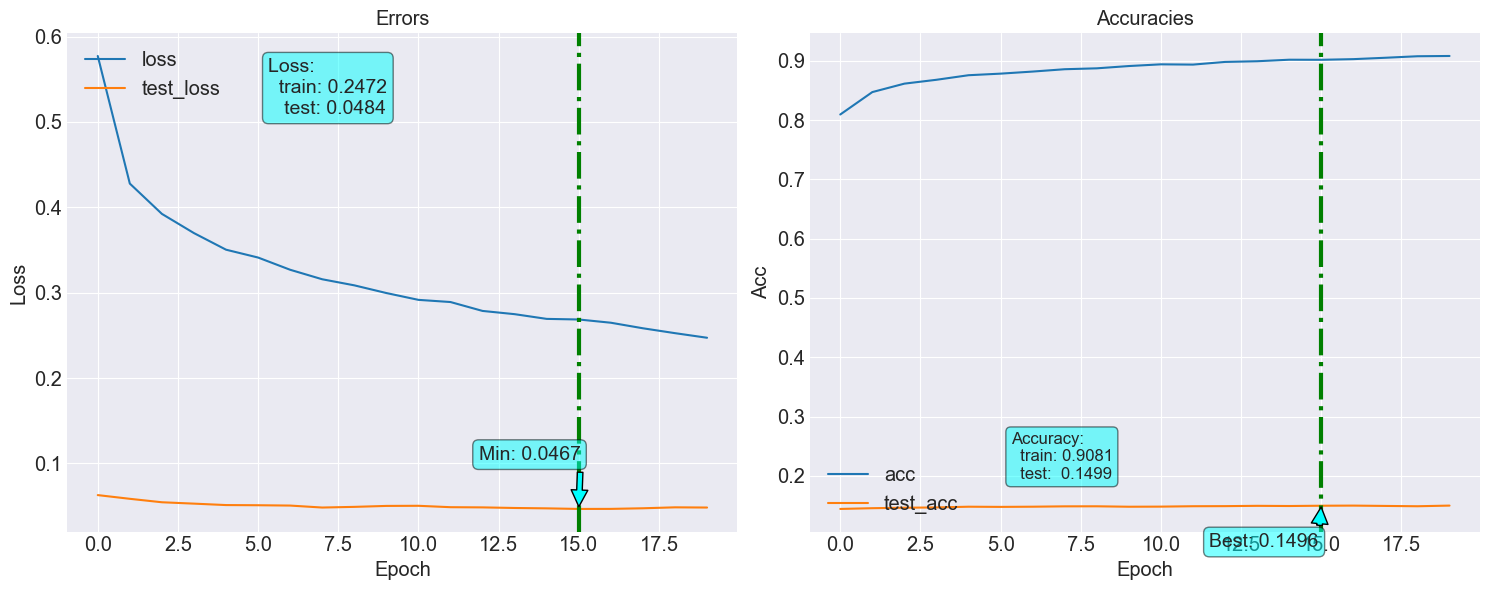

In [15]:
loss_df = pd.DataFrame({
    'epoch' : n_epoch,
    'loss' : loss,
    'test_loss': tloss,
    'acc' : acc,
    'test_acc' : tacc
})

display(loss_df.head())
fn_plot_torch_hist(loss_df)

In [16]:
y_true,y_pred = [],[]
for feat,lbls in train_loader:
    pred = model(feat).detach().cpu().numpy()

In [17]:
# std = StandardScaler()
# X_train = std.fit_transform(X_train)
# X_test = std.transform(X_test)
# # 
# y_train = y_train.to_numpy()
# y_test = y_test.to_numpy()

# X_train.shape, X_test.shape, y_train.shape , y_test.shape

In [18]:
# type(X_train), type(X_test), type(y_train), type(y_test)

Converting to Datasets

In [19]:
# train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) # a we are passing rows of data thats why slices. it is creating dataset for us
# test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [20]:
# train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE) 
# test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)


In [21]:
# train_ds = train_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)
# test_ds = test_ds.cache().prefetch(buffer_size=  tf.data.AUTOTUNE)


In [22]:
# train_ds

In [23]:
# for fetures,labels in  train_ds.take(5):
#     print(fetures.shape,labels.shape)

<h1>Define Model</h1>

In [24]:
# model = tf.keras.Sequential([
#     tf.keras.Input(shape = (33,)),
#     tf.keras.layers.Dense(27,activation='relu'),
#     tf.keras.layers.Dense(21,activation='relu'),
#     tf.keras.layers.Dense(15,activation='relu'),
#     tf.keras.layers.Dense(9,activation='relu'),
#     tf.keras.layers.Dense(4)
# ])

In [25]:
# loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA)
# model.compile(optimizer = optimizer,
#              loss = loss_fn,
#              metrics = ['accuracy'])

In [26]:
# history = model.fit(train_ds,
#                     validation_data=test_ds,
#                     epochs=EPOCHS)

In [27]:
# model.evaluate(train_ds,verbose=2)
# # 

<h1>Prediction</h1>

In [28]:
# y_true,y_pred = [],[]
# for feat,lbls in train_ds:
#     pred = model(feat).numpy()
#     y_true.extend(lbls)
#     y_pred.extend(pred.argmax(axis = 1))
# print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
# print(f'Accuracy : {classification_report(y_true,y_pred)}')

In [29]:
# loss_df = pd.DataFrame(history.history)
# fn_plot_tf_hist(loss_df)